In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import os

DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

file_path = os.path.join(OUTPUT_DIR, "dataset_with_sentiment.xlsx")

df = pd.read_excel(file_path)

Dataset shape: (5715, 26)


,tweet_id,display_name,username,followers,tweet,created_at,lang,user_location,tweet_location,likes,...,location_clean,city_clean,sentiment_roberta,confidence_roberta,polarity_roberta,sentiment_model2,confidence_model2,polarity_model2,sentiment,sentiment_score
0,1406970754688717056,Яizal do,afrkml,350301,Gejala yg ditimbulkan memang umum dan sudah di...,Mon Jun 21 13:42:22 +0000 2021,in,Dukung kami di sini →,NaN,245,...,dukung kami di sini,NaN,negative,0.752307,-0.752307,negative,0.995110,-0.995110,negative,-0.995110
1,1409518162362568960,🍒,claudiaars__,230,Until this minute masih ga habis pikir bisa2ny...,Mon Jun 28 14:24:52 +0000 2021,in,Jakarta,NaN,0,...,jakarta,jakarta,negative,0.996685,-0.996685,negative,0.619597,-0.619597,negative,-0.619597
2,1408483130994946048,R30_K03 🇮🇩,ryuuken86,24,Hari jum'at 24 juni. Guru SMP ku meninggal di ...,Fri Jun 25 17:52:01 +0000 2021,in,Indonesia,NaN,0,...,indonesia,NaN,negative,0.616726,-0.616726,positive,0.891653,0.891653,positive,0.891653
3,1409494375294390016,M Taufik Zoelkifli,emtezet,2127,Singapura sudah akan beranjak dari Pandemi men...,Mon Jun 28 12:50:20 +0000 2021,in,Jakarta,"Cempaka Putih, Indonesia",2,...,cempaka putih indonesia,NaN,positive,0.778616,0.778616,positive,0.954192,0.954192,positive,0.954192
4,1407938212631237120,rahardjoguyub,guyubrahardjo,598,@CNNIndonesia @PutraWadapi Kondisi jakarta yg ...,Thu Jun 24 05:46:42 +0000 2021,in,"DKI Jakarta, Indonesia",NaN,0,...,dki jakarta indonesia,jakarta,neutral,0.654501,0.000000,neutral,0.889500,0.000000,neutral,0.000000


NETWORK GRAPH CONSTRUCTION

In [174]:
print(df["mentions"].dropna().head(10))

4      CNNIndonesia, PutraWadapi
5                  milasantika06
6                     bertanyarl
16                werryhikmatiar
18                    subtanyarl
19                      detikcom
23                   ameamakunai
26                    subtanyarl
33                      mrs_enci
38    edwardsuhadi, KawalCOVID19
Name: mentions, dtype: str


In [175]:
print(type(df["mentions"].dropna().iloc[0]))

<class 'str'>


In [176]:
print(df["reply_to_username"].dropna().head(10))

0             afrkml
4       cnnindonesia
5      milasantika06
6         bertanyarl
11    uncle_gober324
16    werryhikmatiar
18        subtanyarl
19          detikcom
20            j0bbas
21      adiarticuno2
Name: reply_to_username, dtype: str


Extract Mention Edges

In [177]:
mention_edges = []

for _, row in df.iterrows():

    source = str(row["username"]).strip()

    if pd.isna(row["mentions"]):
        continue

    mentions = str(row["mentions"]).split(",")

    for target in mentions:

        target = target.strip()

        if target != "":

            mention_edges.append([
                source,
                target,
                row["sentiment"],
                "mention"
            ])

mention_edges = pd.DataFrame(
    mention_edges,
    columns=[
        "source",
        "target",
        "sentiment",
        "interaction_type"
    ]
)

print("Mention edges:", len(mention_edges))
mention_edges.head()

Mention edges: 1268


,source,target,sentiment,interaction_type
0,guyubrahardjo,CNNIndonesia,neutral,mention
1,guyubrahardjo,PutraWadapi,neutral,mention
2,tikaresianaa,milasantika06,negative,mention
3,albusvenetus,bertanyarl,negative,mention
4,makelarnaga,werryhikmatiar,negative,mention


Extract Reply Edges

In [178]:
reply_edges = df[
    df["reply_to_username"].notna()
].copy()

reply_edges = reply_edges[
    [
        "username",
        "reply_to_username",
        "sentiment"
    ]
]

reply_edges.columns = [
    "source",
    "target",
    "sentiment"
]

reply_edges["interaction_type"] = "reply"

print("Reply edges:", len(reply_edges))
reply_edges.head()

Reply edges: 1388


,source,target,sentiment,interaction_type
0,afrkml,afrkml,negative,reply
4,guyubrahardjo,cnnindonesia,neutral,reply
5,tikaresianaa,milasantika06,negative,reply
6,albusvenetus,bertanyarl,negative,reply
11,dawil_k,uncle_gober324,negative,reply


Combine Edges

In [179]:
edges = pd.concat(
    [
        mention_edges,
        reply_edges
    ],
    ignore_index=True
)

print("Total edges:", len(edges))
edges.head()

Total edges: 2656


,source,target,sentiment,interaction_type
0,guyubrahardjo,CNNIndonesia,neutral,mention
1,guyubrahardjo,PutraWadapi,neutral,mention
2,tikaresianaa,milasantika06,negative,mention
3,albusvenetus,bertanyarl,negative,mention
4,makelarnaga,werryhikmatiar,negative,mention


Self-loops (ignored)

In [180]:
self_loops = edges[
    edges["source"] == edges["target"]
]

print("Self-loops:", len(self_loops))

Self-loops: 779


In [181]:
self_loops = edges[
    edges["source"] == edges["target"]
]

print(self_loops.head(20))

              source           target sentiment interaction_type
113    merdekadotcom    merdekadotcom   neutral          mention
184     tribunbanten     tribunbanten   neutral          mention
481  tribunpontianak  tribunpontianak   neutral          mention
580   beritajatimcom   beritajatimcom  positive          mention
586   beritajatimcom   beritajatimcom   neutral          mention
587      serambinews      serambinews   neutral          mention
588      serambinews      serambinews   neutral          mention
589   beritajatimcom   beritajatimcom   neutral          mention
590      serambinews      serambinews   neutral          mention
591      serambinews      serambinews   neutral          mention
592      serambinews      serambinews   neutral          mention
594  banjarmasinpost  banjarmasinpost   neutral          mention
682  rutanpasangkayu  rutanpasangkayu   neutral          mention
688  rutanpasangkayu  rutanpasangkayu   neutral          mention
696   beritajatimcom   be

Calculate Weight Interaction

In [182]:
edges_weighted = (
    edges
    .groupby(
        [
            "source",
            "target",
            "sentiment"
        ]
    )
    .size()
    .reset_index(name="weight")
)

print(edges_weighted.shape)

edges_weighted.head()

(1887, 4)


,source,target,sentiment,weight
0,0bungkal,polres_ponorogo,neutral,1
1,0jenry1,PNS_Ababil,neutral,1
2,1404stj,1404stj,positive,2
3,1404stj,UNICEF,positive,1
4,1404stj,jokowi,positive,1


In [ ]:
edges_weighted.to_excel(
    os.path.join(OUTPUT_DIR, "weighted_edges.xlsx"),
    index=False
)

edges_weighted.xlsx saved


Build Complete Network

In [184]:
G = nx.from_pandas_edgelist(
    edges_weighted,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 2166
Edges: 1767


Build Sentiment Network

In [185]:
positive_edges = edges_weighted[
    edges_weighted["sentiment"] == "positive"
]

neutral_edges = edges_weighted[
    edges_weighted["sentiment"] == "neutral"
]

negative_edges = edges_weighted[
    edges_weighted["sentiment"] == "negative"
]

In [186]:
G_positive = nx.from_pandas_edgelist(
    positive_edges,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

G_neutral = nx.from_pandas_edgelist(
    neutral_edges,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

G_negative = nx.from_pandas_edgelist(
    negative_edges,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

Network Construction Statistics

In [187]:
network_summary = pd.DataFrame({
    "Network":[
        "Complete",
        "Positive",
        "Neutral",
        "Negative"
    ],
    "Nodes":[
        G.number_of_nodes(),
        G_positive.number_of_nodes(),
        G_neutral.number_of_nodes(),
        G_negative.number_of_nodes()
    ],
    "Edges":[
        G.number_of_edges(),
        G_positive.number_of_edges(),
        G_neutral.number_of_edges(),
        G_negative.number_of_edges()
    ]
})

network_summary

,Network,Nodes,Edges
0,Complete,2166,1767
1,Positive,378,318
2,Neutral,933,757
3,Negative,1081,812


In [188]:
nx.write_gexf(
    G,
    "complete_network.gexf"
)

nx.write_gexf(
    G_positive,
    "positive_network.gexf"
)

nx.write_gexf(
    G_neutral,
    "neutral_network.gexf"
)

nx.write_gexf(
    G_negative,
    "negative_network.gexf"
)

Visualization

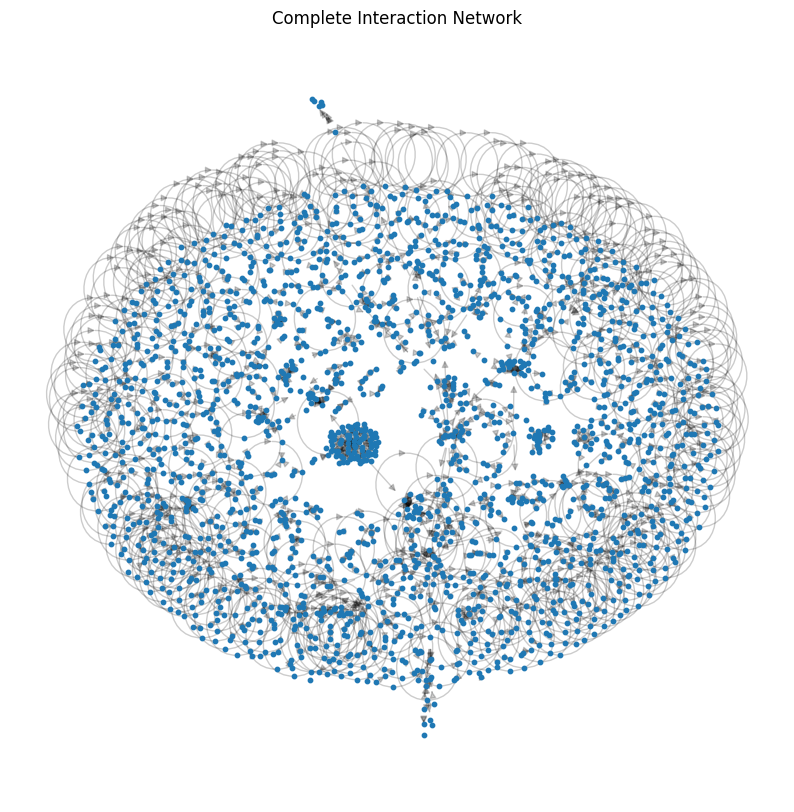

In [189]:
#complete
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title(
    "Complete Interaction Network"
)

plt.axis("off")

plt.show()

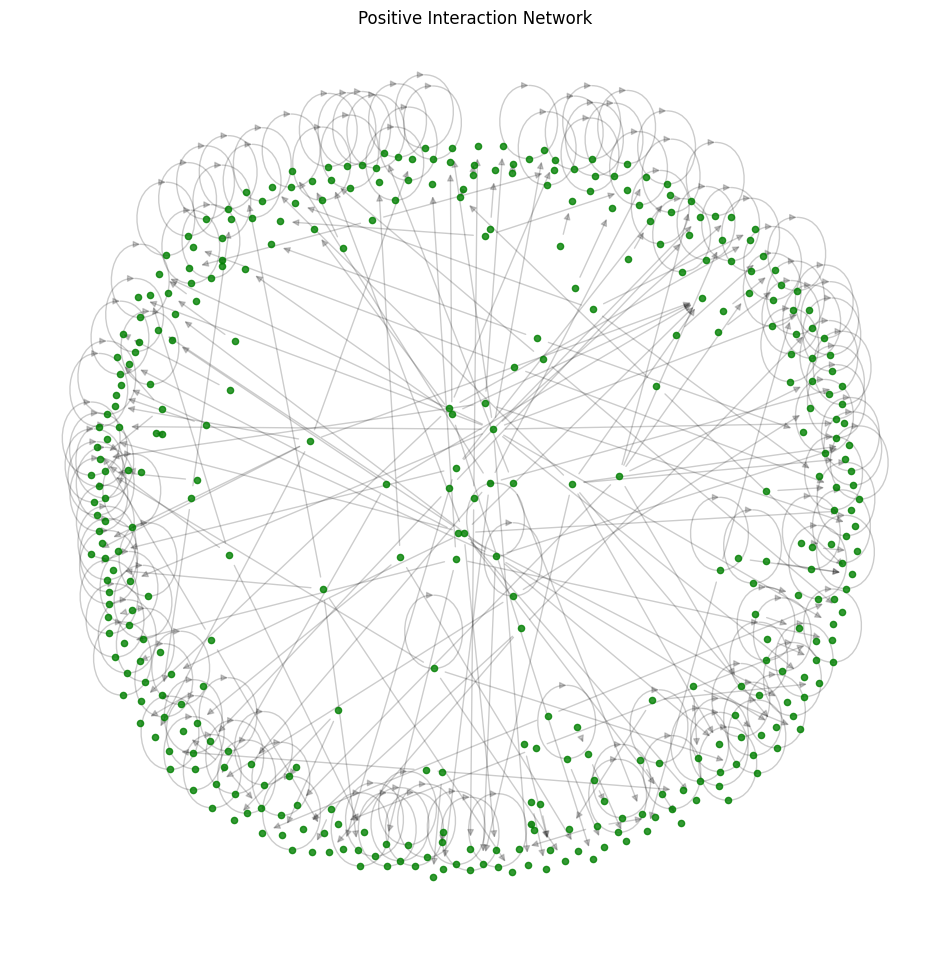

In [190]:
plt.figure(figsize=(12,12))

pos = nx.spring_layout(G_positive, seed=42)

nx.draw_networkx_nodes(
    G_positive,
    pos,
    node_size=20,
    node_color="green",
    alpha=0.8
)

nx.draw_networkx_edges(
    G_positive,
    pos,
    alpha=0.2
)

plt.title("Positive Interaction Network")
plt.axis("off")
plt.show()

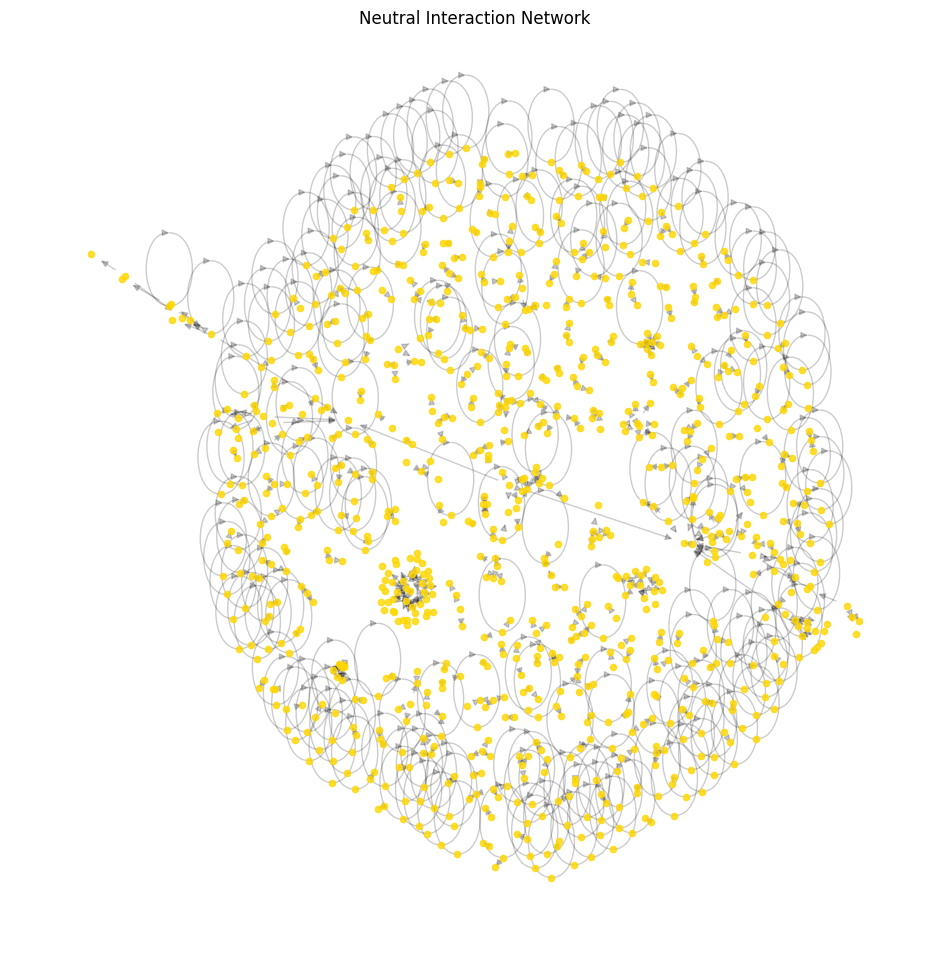

In [191]:
#neutral
plt.figure(figsize=(12,12))

pos = nx.spring_layout(G_neutral, seed=42)

nx.draw_networkx_nodes(
    G_neutral,
    pos,
    node_size=20,
    node_color="gold",
    alpha=0.8
)

nx.draw_networkx_edges(
    G_neutral,
    pos,
    alpha=0.2
)

plt.title("Neutral Interaction Network")
plt.axis("off")
plt.show()

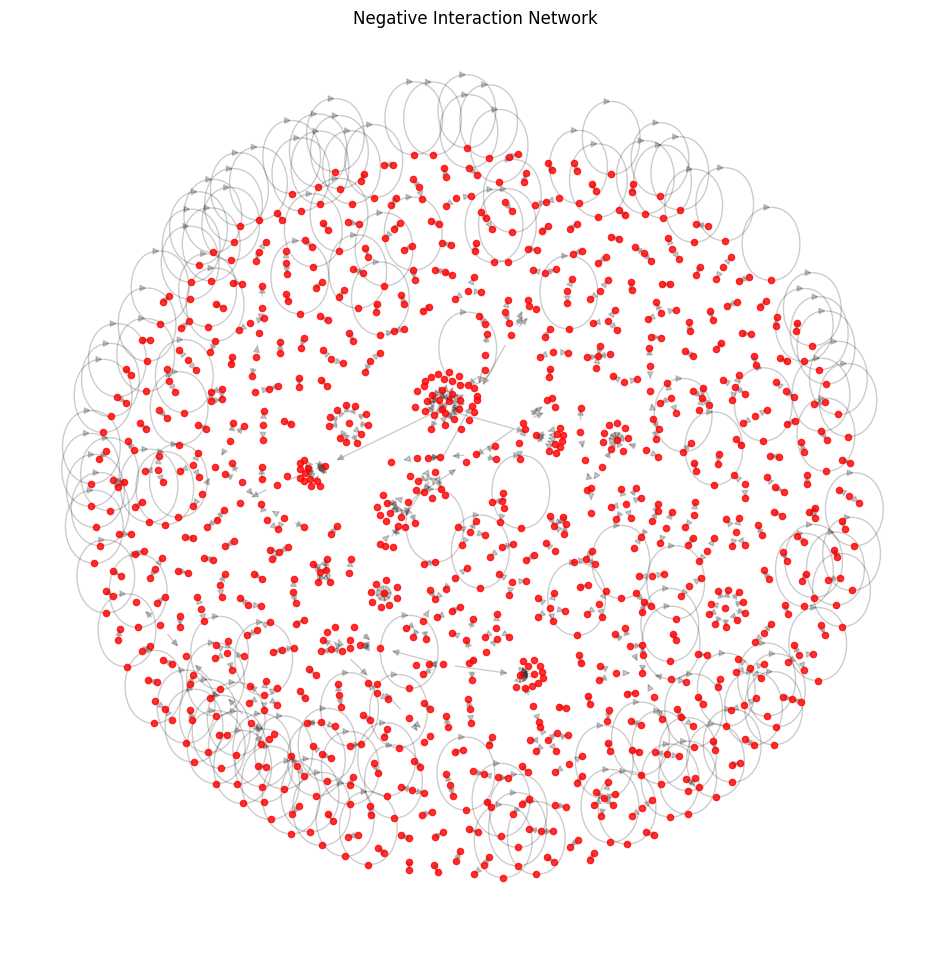

In [192]:
#negative
plt.figure(figsize=(12,12))

pos = nx.spring_layout(G_negative, seed=42)

nx.draw_networkx_nodes(
    G_negative,
    pos,
    node_size=20,
    node_color="red",
    alpha=0.8
)

nx.draw_networkx_edges(
    G_negative,
    pos,
    alpha=0.2
)

plt.title("Negative Interaction Network")
plt.axis("off")
plt.show()

In [ ]:
networks = [
    (G, "Complete network", "#1f77b4"),
    (G_positive, "Positive network", "#2ca02c"),
    (G_neutral, "Neutral network", "#d4a017"),
    (G_negative, "Negative network", "#d62728"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, (graph, title, color) in zip(axes, networks):
    G_viz = graph.copy()
    G_viz.remove_edges_from(nx.selfloop_edges(G_viz))
    
    # Keep only the largest weakly connected component
    largest_cc = max(nx.weakly_connected_components(G_viz), key=len)
    G_viz = G_viz.subgraph(largest_cc).copy()
    
    n_shown = G_viz.number_of_nodes()
    n_total = graph.number_of_nodes()
    
    pos = nx.spring_layout(G_viz, seed=42, k=0.5, iterations=100)
    
    # Size nodes by degree so hubs are visually prominent
    degrees = dict(G_viz.degree())
    node_sizes = [20 + degrees[n] * 3 for n in G_viz.nodes()]
    
    nx.draw_networkx_nodes(G_viz, pos, ax=ax, node_size=node_sizes, node_color=color, alpha=0.75)
    nx.draw_networkx_edges(G_viz, pos, ax=ax, alpha=0.2, width=0.6, arrowsize=6)
    
    ax.set_title(f"{title} (largest component, {n_shown}/{n_total} nodes)", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_interaction_networks_lcc.png"), dpi=300, bbox_inches="tight")
plt.show()

------------------ NETWORK-LEVEL ANALYSIS -----------------------

Complete Network

In [193]:
#number of edges and nodes
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

Nodes : 2166
Edges : 1767


In [194]:
#average degree
degrees = dict(G.degree())

avg_degree = (
    sum(degrees.values())
    / G.number_of_nodes()
)

print(
    "Average Degree:",
    round(avg_degree, 4)
)

Average Degree: 1.6316


In [195]:
#density
density = nx.density(G)

print(
    "Density:",
    round(density, 6)
)

Density: 0.000377


In [196]:
#largest connected component
largest_cc = max(
    nx.weakly_connected_components(G),
    key=len
)

subgraph = G.subgraph(
    largest_cc
).copy()

print(
    "Nodes in largest component:",
    subgraph.number_of_nodes()
)

Nodes in largest component: 172


In [197]:
#average path length
apl = nx.average_shortest_path_length(
    subgraph.to_undirected()
)

print(
    "Average Path Length:",
    round(apl,4)
)

Average Path Length: 5.4838


In [198]:
#diameter
diameter = nx.diameter(
    subgraph.to_undirected()
)

print(
    "Diameter:",
    diameter
)

Diameter: 12


In [199]:
#community detection
import community as community_louvain
partition = community_louvain.best_partition(
    G.to_undirected(),
    random_state=42
)

num_communities = len(
    set(partition.values())
)

print(
    "Communities:",
    num_communities
)

Communities: 861


In [200]:
#modularity
modularity = community_louvain.modularity(
    partition,
    G.to_undirected()
)

print(
    "Modularity:",
    round(modularity, 4)
)

Modularity: 0.9868


In [201]:
complete_metrics = pd.DataFrame({
    "Network":["Complete"],
    "Nodes":[G.number_of_nodes()],
    "Edges":[G.number_of_edges()],
    "Average Degree":[avg_degree],
    "Density":[density],
    "Average Path Length":[apl],
    "Diameter":[diameter],
    "Communities":[num_communities],
    "Modularity":[modularity]
})

complete_metrics

,Network,Nodes,Edges,Average Degree,Density,Average Path Length,Diameter,Communities,Modularity
0,Complete,2166,1767,1.631579,0.000377,5.483816,12,861,0.986824


Positive Network

In [202]:
#edges and nodes
print("Positive Network")

print("Nodes :", G_positive.number_of_nodes())
print("Edges :", G_positive.number_of_edges())

Positive Network
Nodes : 378
Edges : 318


In [203]:
#average degree
degrees = dict(G_positive.degree())

avg_degree_positive = (
    sum(degrees.values())
    / G_positive.number_of_nodes()
)

print(
    "Average Degree:",
    round(avg_degree_positive, 4)
)

Average Degree: 1.6825


In [204]:
#density
density_positive = nx.density(G_positive)

print(
    "Density:",
    round(density_positive, 6)
)

Density: 0.002231


In [205]:
#largest connected components
largest_cc_positive = max(
    nx.weakly_connected_components(G_positive),
    key=len
)

subgraph_positive = G_positive.subgraph(
    largest_cc_positive
).copy()

print(
    "Largest Component Nodes:",
    subgraph_positive.number_of_nodes()
)

Largest Component Nodes: 38


In [206]:
#average path length
apl_positive = nx.average_shortest_path_length(
    subgraph_positive.to_undirected()
)

print(
    "Average Path Length:",
    round(apl_positive, 4)
)

Average Path Length: 3.7525


In [207]:
#diameter
diameter_positive = nx.diameter(
    subgraph_positive.to_undirected()
)

print(
    "Diameter:",
    diameter_positive
)

Diameter: 8


In [208]:
#community
partition_positive = (
    community_louvain.best_partition(
        G_positive.to_undirected(),
        random_state=42
    )
)

num_communities_positive = len(
    set(partition_positive.values())
)

print(
    "Communities:",
    num_communities_positive
)

Communities: 200


In [209]:
#modularity
modularity_positive = (
    community_louvain.modularity(
        partition_positive,
        G_positive.to_undirected()
    )
)

print(
    "Modularity:",
    round(modularity_positive, 4)
)

Modularity: 0.9828


In [210]:
positive_metrics = pd.DataFrame({
    "Network":["Positive"],
    "Nodes":[G_positive.number_of_nodes()],
    "Edges":[G_positive.number_of_edges()],
    "Average Degree":[avg_degree_positive],
    "Density":[density_positive],
    "Average Path Length":[apl_positive],
    "Diameter":[diameter_positive],
    "Communities":[num_communities_positive],
    "Modularity":[modularity_positive]
})

positive_metrics

,Network,Nodes,Edges,Average Degree,Density,Average Path Length,Diameter,Communities,Modularity
0,Positive,378,318,1.68254,0.002231,3.752489,8,200,0.982803


Neutral Network

In [211]:
#nodes and edges
print("Neutral Network")

print("Nodes :", G_neutral.number_of_nodes())
print("Edges :", G_neutral.number_of_edges())

Neutral Network
Nodes : 933
Edges : 757


In [212]:
#average degree
degrees = dict(G_neutral.degree())

avg_degree_neutral = (
    sum(degrees.values())
    / G_neutral.number_of_nodes()
)

print(
    "Average Degree:",
    round(avg_degree_neutral, 4)
)

Average Degree: 1.6227


In [213]:
#density
density_neutral = nx.density(G_neutral)

print(
    "Density:",
    round(density_neutral, 6)
)

Density: 0.000871


In [214]:
#largest connected components
largest_cc_neutral = max(
    nx.weakly_connected_components(G_neutral),
    key=len
)

subgraph_neutral = G_neutral.subgraph(
    largest_cc_neutral
).copy()

print(
    "Largest Component Nodes:",
    subgraph_neutral.number_of_nodes()
)

Largest Component Nodes: 59


In [215]:
#average path length
apl_neutral = nx.average_shortest_path_length(
    subgraph_neutral.to_undirected()
)

print(
    "Average Path Length:",
    round(apl_neutral, 4)
)

Average Path Length: 4.2455


In [216]:
#diameter
diameter_neutral = nx.diameter(
    subgraph_neutral.to_undirected()
)

print(
    "Diameter:",
    diameter_neutral
)

Diameter: 10


In [217]:
#community
partition_neutral = (
    community_louvain.best_partition(
        G_neutral.to_undirected(),
        random_state=42
    )
)

num_communities_neutral = len(
    set(partition_neutral.values())
)

print(
    "Communities:",
    num_communities_neutral
)

Communities: 426


In [218]:
#modularity
modularity_neutral = (
    community_louvain.modularity(
        partition_neutral,
        G_neutral.to_undirected()
    )
)

print(
    "Modularity:",
    round(modularity_neutral, 4)
)

Modularity: 0.9876


In [219]:
neutral_metrics = pd.DataFrame({
    "Network":["Neutral"],
    "Nodes":[G_neutral.number_of_nodes()],
    "Edges":[G_neutral.number_of_edges()],
    "Average Degree":[avg_degree_neutral],
    "Density":[density_neutral],
    "Average Path Length":[apl_neutral],
    "Diameter":[diameter_neutral],
    "Communities":[num_communities_neutral],
    "Modularity":[modularity_neutral]
})

neutral_metrics

,Network,Nodes,Edges,Average Degree,Density,Average Path Length,Diameter,Communities,Modularity
0,Neutral,933,757,1.622722,0.000871,4.24547,10,426,0.98761


Negative Network

In [220]:
#nodes and edges
print("Negative Network")

print("Nodes :", G_negative.number_of_nodes())
print("Edges :", G_negative.number_of_edges())

Negative Network
Nodes : 1081
Edges : 812


In [221]:
#average degree
degrees = dict(G_negative.degree())

avg_degree_negative = (
    sum(degrees.values())
    / G_negative.number_of_nodes()
)

print(
    "Average Degree:",
    round(avg_degree_negative, 4)
)

Average Degree: 1.5023


In [222]:
#density
density_negative = nx.density(G_negative)

print(
    "Density:",
    round(density_negative, 6)
)

Density: 0.000696


In [223]:
#largest connected components
largest_cc_negative = max(
    nx.weakly_connected_components(G_negative),
    key=len
)

subgraph_negative = G_negative.subgraph(
    largest_cc_negative
).copy()

print(
    "Largest Component Nodes:",
    subgraph_negative.number_of_nodes()
)

Largest Component Nodes: 58


In [224]:
#average path length
apl_negative = nx.average_shortest_path_length(
    subgraph_negative.to_undirected()
)

print(
    "Average Path Length:",
    round(apl_negative, 4)
)

Average Path Length: 2.6201


In [225]:
#diameter
diameter_negative = nx.diameter(
    subgraph_negative.to_undirected()
)

print(
    "Diameter:",
    diameter_negative
)

Diameter: 5


In [226]:
#community
partition_negative = (
    community_louvain.best_partition(
        G_negative.to_undirected(),
        random_state=42
    )
)

num_communities_negative = len(
    set(partition_negative.values())
)

print(
    "Communities:",
    num_communities_negative
)

Communities: 426


In [227]:
#modularity
modularity_negative = (
    community_louvain.modularity(
        partition_negative,
        G_negative.to_undirected()
    )
)

print(
    "Modularity:",
    round(modularity_negative, 4)
)

Modularity: 0.9897


In [228]:
negative_metrics = pd.DataFrame({
    "Network":["Negative"],
    "Nodes":[G_negative.number_of_nodes()],
    "Edges":[G_negative.number_of_edges()],
    "Average Degree":[avg_degree_negative],
    "Density":[density_negative],
    "Average Path Length":[apl_negative],
    "Diameter":[diameter_negative],
    "Communities":[num_communities_negative],
    "Modularity":[modularity_negative]
})

negative_metrics

,Network,Nodes,Edges,Average Degree,Density,Average Path Length,Diameter,Communities,Modularity
0,Negative,1081,812,1.502313,0.000696,2.620085,5,426,0.989735


All Network Level Analysis

In [229]:
network_metrics = pd.concat([
    complete_metrics,
    positive_metrics,
    neutral_metrics,
    negative_metrics
], ignore_index=True)

network_metrics

,Network,Nodes,Edges,Average Degree,Density,Average Path Length,Diameter,Communities,Modularity
0,Complete,2166,1767,1.631579,0.000377,5.483816,12,861,0.986824
1,Positive,378,318,1.682540,0.002231,3.752489,8,200,0.982803
2,Neutral,933,757,1.622722,0.000871,4.245470,10,426,0.987610
3,Negative,1081,812,1.502313,0.000696,2.620085,5,426,0.989735


In [ ]:
network_metrics.to_excel(
    os.path.join(OUTPUT_DIR, "network_level_metrics.xlsx"),
    index=False
)

print("network_level_metrics.xlsx saved")

network_level_metrics.xlsx saved


----------------- NODE-LEVEL ANALYSIS ---------------------

Complete Network

In [231]:
#In Degree
in_degree = dict(G.in_degree())

in_degree_df = pd.DataFrame(
    in_degree.items(),
    columns=[
        "username",
        "in_degree"
    ]
)

in_degree_df.sort_values(
    "in_degree",
    ascending=False
).head(10)

,username,in_degree
106,KemenkesRI,19
98,kegblgnunfaedh,16
130,convomf,16
162,tanyarlfes,13
140,tanyakanrl,13
33,bertanyarl,10
170,helenamantra,6
65,amti_d19,6
66,thinkway_ID,6
484,aniesbaswedan,6


In [232]:
#Out Degree
out_degree = dict(G.out_degree())

out_degree_df = pd.DataFrame(
    out_degree.items(),
    columns=[
        "username",
        "out_degree"
    ]
)

out_degree_df.sort_values(
    "out_degree",
    ascending=False
).head(10)

,username,out_degree
744,grok,84
1699,rielbrazoes,20
1464,nanangshmhmkn,17
52,abanggeutanyoe,11
1196,khoirilanwar_,10
314,basroid,10
1936,tamerlane9470,9
2115,yoga_padmadi,9
1922,syahdu711,9
1834,shintaeffendi,9


In [233]:
#Betweenness
betweenness = nx.betweenness_centrality(
    G,
    normalized=True
)

betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=[
        "username",
        "betweenness"
    ]
)

betweenness_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

,username,betweenness
583,drevachaniago,2.134444e-06
107,mariaalkaff_,1.067222e-06
75,valiisaa,1.067222e-06
1150,kotajakpus,1.067222e-06
537,dokterapin,8.537778e-07
71,aceh,4.268889e-07
717,ghanjiangyi,2.134444e-07
1657,rsabhk,2.134444e-07
4,1404stj,0.000000e+00
5,UNICEF,0.000000e+00


In [234]:
#pagerank
pagerank = nx.pagerank(
    G,
    weight="weight"
)

pagerank_df = pd.DataFrame(
    pagerank.items(),
    columns=[
        "username",
        "pagerank"
    ]
)

pagerank_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

,username,pagerank
95,afrkml,0.003688
1113,tirta_cipeng,0.003668
556,dinkesjateng,0.003091
98,kegblgnunfaedh,0.002749
130,convomf,0.002663
1136,merdekadotcom,0.002514
162,tanyarlfes,0.002281
140,tanyakanrl,0.002197
181,angewwie,0.002129
33,bertanyarl,0.001843


In [235]:
centrality_complete = (
    pagerank_df
    .merge(
        in_degree_df,
        on="username"
    )
    .merge(
        out_degree_df,
        on="username"
    )
    .merge(
        betweenness_df,
        on="username"
    )
)

centrality_complete.head()

,username,pagerank,in_degree,out_degree,betweenness
0,0bungkal,0.000206,0,1,0.0
1,polres_ponorogo,0.000381,1,0,0.0
2,0jenry1,0.000206,0,1,0.0
3,PNS_Ababil,0.000381,1,0,0.0
4,1404stj,0.000359,1,3,0.0


In [236]:
#rank based on PageRank
top_complete = (
    centrality_complete
    .sort_values(
        "pagerank",
        ascending=False
    )
)

top_complete.head(20)

,username,pagerank,in_degree,out_degree,betweenness
95,afrkml,0.003688,4,1,0.000000
1113,tirta_cipeng,0.003668,3,1,0.000000
556,dinkesjateng,0.003091,3,1,0.000000
98,kegblgnunfaedh,0.002749,16,0,0.000000
130,convomf,0.002663,16,0,0.000000
1136,merdekadotcom,0.002514,2,1,0.000000
162,tanyarlfes,0.002281,13,0,0.000000
140,tanyakanrl,0.002197,13,0,0.000000
181,angewwie,0.002129,2,1,0.000000
33,bertanyarl,0.001843,10,0,0.000000


In [ ]:
top_complete.to_excel(
    os.path.join(OUTPUT_DIR, "complete_network_centrality.xlsx"),
    index=False
)

Positive Network

In [238]:
#in Degree
in_degree_positive = dict(
    G_positive.in_degree()
)

in_degree_positive_df = pd.DataFrame(
    in_degree_positive.items(),
    columns=[
        "username",
        "in_degree"
    ]
)

in_degree_positive_df.sort_values(
    "in_degree",
    ascending=False
).head(10)

,username,in_degree
143,KemenkesRI,5
113,axa_mandiri,3
238,aniesbaswedan,3
24,helenamantra,2
93,PjNanaSudjana,2
2,jokowi,2
36,ainurohman,2
147,aik_arif,2
245,AXA_Mandiri,2
233,tni_ad,2


In [239]:
#out-degree
out_degree_positive = dict(
    G_positive.out_degree()
)

out_degree_positive_df = pd.DataFrame(
    out_degree_positive.items(),
    columns=[
        "username",
        "out_degree"
    ]
)

out_degree_positive_df.sort_values(
    "out_degree",
    ascending=False
).head(10)

,username,out_degree
119,grok,12
340,syahdu711,9
267,pkm_polowijen,7
373,yusufgunawan,7
225,mariaalkaff_,6
132,guyubrahardjo,6
171,jack_the_repear,5
219,maftuhahmad82,5
59,caksollwife,4
146,hariankompas,4


In [240]:
#Betweenness Centrality
betweenness_positive = nx.betweenness_centrality(
    G_positive,
    normalized=True
)

betweenness_positive_df = pd.DataFrame(
    betweenness_positive.items(),
    columns=[
        "username",
        "betweenness"
    ]
)

betweenness_positive_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

,username,betweenness
287,rsabhk,0.000007
1,UNICEF,0.000000
2,jokowi,0.000000
3,93dancan,0.000000
4,vincentrcrd,0.000000
5,_fauzanx4,0.000000
6,_lavraa,0.000000
7,_lforlucky,0.000000
8,budibongg,0.000000
9,abughaziiii,0.000000


In [241]:
#PageRank
pagerank_positive = nx.pagerank(
    G_positive,
    weight="weight"
)

pagerank_positive_df = pd.DataFrame(
    pagerank_positive.items(),
    columns=[
        "username",
        "pagerank"
    ]
)

pagerank_positive_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

,username,pagerank
32,anne_khanza,0.005618
33,anotherorion,0.005618
336,sitimustiani,0.005618
337,sksui,0.005618
22,amaninanaeeim,0.005618
335,sinaridigitalid,0.005618
338,sunlife_id,0.005618
339,susierna,0.005618
44,bempolimediajkt,0.005618
43,bemfkmuniska,0.005618


In [242]:
centrality_positive = (
    pagerank_positive_df
    .merge(
        in_degree_positive_df,
        on="username"
    )
    .merge(
        out_degree_positive_df,
        on="username"
    )
    .merge(
        betweenness_positive_df,
        on="username"
    )
)

centrality_positive.head()

,username,pagerank,in_degree,out_degree,betweenness
0,1404stj,0.001468,1,3,0.0
1,UNICEF,0.001156,1,0,0.0
2,jokowi,0.001395,2,0,0.0
3,93dancan,0.000844,0,1,0.0
4,vincentrcrd,0.001561,1,0,0.0


In [243]:
top_positive = (
    centrality_positive
    .sort_values(
        "pagerank",
        ascending=False
    )
)

top_positive.head(20)

,username,pagerank,in_degree,out_degree,betweenness
32,anne_khanza,0.005618,1,1,0.0
33,anotherorion,0.005618,1,1,0.0
336,sitimustiani,0.005618,1,1,0.0
337,sksui,0.005618,1,1,0.0
22,amaninanaeeim,0.005618,1,1,0.0
335,sinaridigitalid,0.005618,1,1,0.0
338,sunlife_id,0.005618,1,1,0.0
339,susierna,0.005618,1,1,0.0
44,bempolimediajkt,0.005618,1,1,0.0
43,bemfkmuniska,0.005618,1,1,0.0


In [ ]:
top_positive.to_excel(
    os.path.join(OUTPUT_DIR, "positive_network_centrality.xlsx"),
    index=False
)

print(
    "positive_network_centrality.xlsx saved"
)

positive_network_centrality.xlsx saved


Neutral Network

In [245]:
#In Degree
in_degree_neutral = dict(
    G_neutral.in_degree()
)

in_degree_neutral_df = pd.DataFrame(
    in_degree_neutral.items(),
    columns=[
        "username",
        "in_degree"
    ]
)

in_degree_neutral_df.sort_values(
    "in_degree",
    ascending=False
).head(10)

,username,in_degree
45,KemenkesRI,12
26,amti_d19,6
27,thinkway_ID,6
436,DGHisham,4
44,DKIJakarta,4
439,Khairykj,4
438,KKMPutrajaya,4
539,DITJEN_PAS,4
160,DivHumas_Polri,3
239,tanyarlfes,3


In [246]:
#Out Degree
out_degree_neutral = dict(
    G_neutral.out_degree()
)

out_degree_neutral_df = pd.DataFrame(
    out_degree_neutral.items(),
    columns=[
        "username",
        "out_degree"
    ]
)

out_degree_neutral_df.sort_values(
    "out_degree",
    ascending=False
).head(10)

,username,out_degree
289,grok,44
729,rielbrazoes,15
615,nanangshmhmkn,10
911,yoga_padmadi,9
43,aiadigibuy,8
548,linmaskotasolo,6
472,kotajakpus,6
399,inewsprob,6
896,wewantamar,5
842,tamerlane9470,5


In [247]:
#Betweenness
betweenness_neutral = nx.betweenness_centrality(
    G_neutral,
    normalized=True
)

betweenness_neutral_df = pd.DataFrame(
    betweenness_neutral.items(),
    columns=[
        "username",
        "betweenness"
    ]
)

betweenness_neutral_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

,username,betweenness
472,kotajakpus,0.000006
372,valiisaa,0.000001
901,widodo731,0.000000
20,bertanyarl,0.000000
917,chep_ec,0.000000
916,bojonebojoku,0.000000
2,0jenry1,0.000000
6,4n15fuad,0.000000
7,nmonarizqa,0.000000
8,50percenthell,0.000000


In [248]:
#Page Rank
pagerank_neutral = nx.pagerank(
    G_neutral,
    weight="weight"
)

pagerank_neutral_df = pd.DataFrame(
    pagerank_neutral.items(),
    columns=[
        "username",
        "pagerank"
    ]
)

pagerank_neutral_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

,username,pagerank
466,merdekadotcom,0.005233
210,dokterapin,0.005233
217,dinkesjateng,0.005233
341,halo_bandung,0.003310
50,biofarmaid,0.003130
45,KemenkesRI,0.002889
923,yuliastuti8721,0.002830
380,humaspolsekup01,0.002830
921,youthssfm,0.002830
342,halodocid,0.002830


In [249]:
centrality_neutral = (
    pagerank_neutral_df
    .merge(
        in_degree_neutral_df,
        on="username"
    )
    .merge(
        out_degree_neutral_df,
        on="username"
    )
    .merge(
        betweenness_neutral_df,
        on="username"
    )
)

centrality_neutral.head()

,username,pagerank,in_degree,out_degree,betweenness
0,0bungkal,0.000426,0,1,0.0
1,polres_ponorogo,0.000788,1,0,0.0
2,0jenry1,0.000426,0,1,0.0
3,PNS_Ababil,0.000788,1,0,0.0
4,1minggu1cerita,0.000426,0,1,0.0


In [250]:
top_neutral = (
    centrality_neutral
    .sort_values(
        "pagerank",
        ascending=False
    )
)

top_neutral.head(20)

,username,pagerank,in_degree,out_degree,betweenness
466,merdekadotcom,0.005233,2,1,0.0
210,dokterapin,0.005233,2,1,0.0
217,dinkesjateng,0.005233,2,1,0.0
341,halo_bandung,0.003310,2,1,0.0
50,biofarmaid,0.003130,2,1,0.0
45,KemenkesRI,0.002889,12,0,0.0
923,yuliastuti8721,0.002830,1,1,0.0
380,humaspolsekup01,0.002830,1,1,0.0
921,youthssfm,0.002830,1,1,0.0
342,halodocid,0.002830,1,1,0.0


In [ ]:
top_neutral.to_excel(
    os.path.join(OUTPUT_DIR, "neutral_network_centrality.xlsx"),
    index=False
)

print(
    "neutral_network_centrality.xlsx saved"
)

neutral_network_centrality.xlsx saved


Negative Network

In [252]:
#In Degree
in_degree_negative = dict(
    G_negative.in_degree()
)

in_degree_negative_df = pd.DataFrame(
    in_degree_negative.items(),
    columns=[
        "username",
        "in_degree"
    ]
)

in_degree_negative_df.sort_values(
    "in_degree",
    ascending=False
).head(10)

,username,in_degree
63,convomf,14
49,kegblgnunfaedh,13
78,tanyarlfes,10
424,tanyakanrl,9
67,bertanyarl,8
89,AREAJULID,5
35,valiisaa,4
65,detikcom,4
16,gayung_aer,4
14,arifbsantoso,4


In [253]:
#Out Degree
out_degree_negative = dict(
    G_negative.out_degree()
)

out_degree_negative_df = pd.DataFrame(
    out_degree_negative.items(),
    columns=[
        "username",
        "out_degree"
    ]
)

out_degree_negative_df.sort_values(
    "out_degree",
    ascending=False
).head(10)

,username,out_degree
393,grok,34
19,abanggeutanyoe,11
170,basroid,10
612,khoirilanwar_,10
747,nanangshmhmkn,9
948,tamerlane9470,7
345,faishalishal5,7
96,antmegapolitan,6
850,rielbrazoes,6
902,shintaeffendi,6


In [254]:
#Betweenness
betweenness_negative = nx.betweenness_centrality(
    G_negative,
    normalized=True
)

betweenness_negative_df = pd.DataFrame(
    betweenness_negative.items(),
    columns=[
        "username",
        "betweenness"
    ]
)

betweenness_negative_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

,username,betweenness
303,drevachaniago,0.000005
295,dokterapin,0.000002
31,aceh,0.000002
24,HumorJonTampan,0.000000
1065,yusupsomadinata,0.000000
1064,yuliastuti8721,0.000000
9,_banyoe,0.000000
1080,hamsterlands,0.000000
0,6v66le,0.000000
1,dibsturb,0.000000


In [255]:
#PageRank
pagerank_negative = nx.pagerank(
    G_negative,
    weight="weight"
)

pagerank_negative_df = pd.DataFrame(
    pagerank_negative.items(),
    columns=[
        "username",
        "pagerank"
    ]
)

pagerank_negative_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

,username,pagerank
47,afrkml,0.005761
63,convomf,0.005388
49,kegblgnunfaedh,0.004988
78,tanyarlfes,0.003939
424,tanyakanrl,0.003618
67,bertanyarl,0.003611
634,klikdokter_id,0.003066
661,lemihealth_id,0.003066
659,layarpixel,0.003066
657,kyhquintessence,0.003066


In [256]:
centrality_negative = (
    pagerank_negative_df
    .merge(
        in_degree_negative_df,
        on="username"
    )
    .merge(
        out_degree_negative_df,
        on="username"
    )
    .merge(
        betweenness_negative_df,
        on="username"
    )
)

centrality_negative.head()

,username,pagerank,in_degree,out_degree,betweenness
0,6v66le,0.000463,0,2,0.0
1,dibsturb,0.000659,1,0,0.0
2,kenmeong,0.000659,1,0,0.0
3,99cheeze,0.000463,0,1,0.0
4,bronistay,0.000856,1,0,0.0


In [257]:
top_negative = (
    centrality_negative
    .sort_values(
        "pagerank",
        ascending=False
    )
)

top_negative.head(20)

,username,pagerank,in_degree,out_degree,betweenness
47,afrkml,0.005761,3,1,0.0
63,convomf,0.005388,14,0,0.0
49,kegblgnunfaedh,0.004988,13,0,0.0
78,tanyarlfes,0.003939,10,0,0.0
424,tanyakanrl,0.003618,9,0,0.0
67,bertanyarl,0.003611,8,0,0.0
634,klikdokter_id,0.003066,1,1,0.0
661,lemihealth_id,0.003066,1,1,0.0
659,layarpixel,0.003066,1,1,0.0
657,kyhquintessence,0.003066,1,1,0.0


In [ ]:
top_negative.to_excel(
    os.path.join(OUTPUT_DIR, "negative_network_centrality.xlsx"),
    index=False
)

print(
    "negative_network_centrality.xlsx saved"
)

negative_network_centrality.xlsx saved
